# 🏏 IPL Statistical Analysis Notebook

## 📊 Objective
This notebook focuses on **statistical insights** from IPL data using:

- Descriptive Statistics
- Probability-based insights
- Performance metrics
- Distribution analysis

---

## 🎯 Key Goals
- Analyze batting & bowling performance statistically
- Understand run distributions
- Evaluate match outcomes using probability
- Identify patterns using statistical methods

## 📦 IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

## 📂 LOAD DATA

In [2]:
matches = pd.read_csv("../data/raw_data/ipl_matches_data.csv", encoding="latin1")
deliveries = pd.read_csv("../data/raw_data/ball_by_ball_data.csv", encoding="latin1")
players = pd.read_csv("../data/raw_data/players-data-updated.csv", encoding="latin1")
teams = pd.read_csv("../data/raw_data/teams_data.csv", encoding="latin1")

matches.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result,stage
0,335982,2008,6,Bangalore,18-04-2008,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,field,Kolkata Knight Riders,140.0,NaN,46.0,win,NaN
1,1082591,2017,6,Hyderabad,05-04-2017,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,15.0,win,NaN
2,1082592,2017,6,Pune,06-04-2017,Indian Premier League,2.0,male,T20,T20,...,Rising Pune Supergiant,Rising Pune Supergiant,Mumbai Indians,field,Rising Pune Supergiant,NaN,7.0,36.0,win,NaN
3,1082593,2017,6,Rajkot,07-04-2017,Indian Premier League,3.0,male,T20,T20,...,Kolkata Knight Riders,Gujarat Lions,Kolkata Knight Riders,field,Kolkata Knight Riders,NaN,10.0,57.0,win,NaN
4,1082594,2017,6,Indore,08-04-2017,Indian Premier League,4.0,male,T20,T20,...,Punjab Kings,Punjab Kings,Rising Pune Supergiant,field,Punjab Kings,NaN,6.0,71.0,win,NaN


## 🔍 DESCRIPTIVE STATISTICS

In [3]:
# Summary statistics
deliveries[['batter_runs', 'total_runs']].describe()

,batter_runs,total_runs
count,278205.000000,278205.00000
mean,1.277378,1.34535
std,1.651107,1.63762
min,0.000000,0.00000
25%,0.000000,0.00000
50%,1.000000,1.00000
75%,1.000000,1.00000
max,6.000000,7.00000


## 📊 RUN DISTRIBUTION (PROBABILITY VIEW)

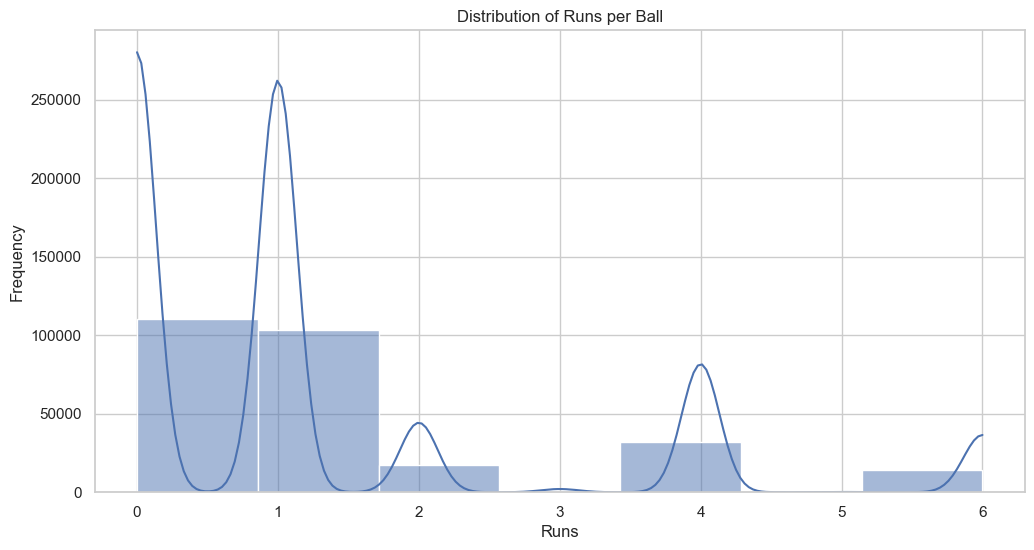

In [4]:
sns.histplot(deliveries['batter_runs'], bins=7, kde=True)

plt.title("Distribution of Runs per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")

plt.show()

## 📈 PROBABILITY OF SCORING RUNS

In [5]:
run_prob = deliveries['batter_runs'].value_counts(normalize=True).sort_index()
run_prob

batter_runs
0    0.396291
1    0.370903
2    0.062630
3    0.002915
4    0.115429
5    0.000241
6    0.051591
Name: proportion, dtype: float64

## ⚡STRIKE RATE DISTRIBUTION

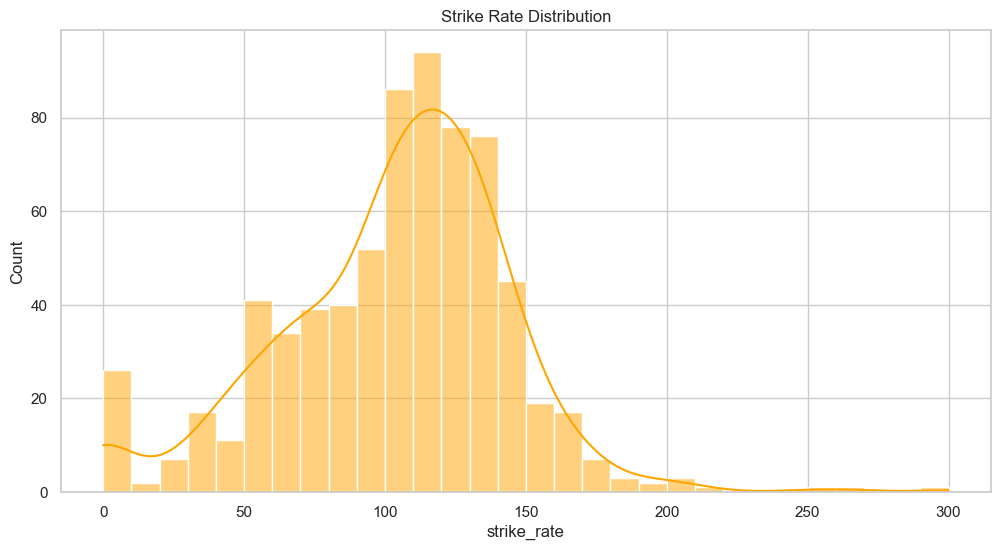

In [6]:
batsman = deliveries.groupby('batter').agg(
    runs=('batter_runs', 'sum'),
    balls=('batter_runs', 'count')
)

batsman['strike_rate'] = (batsman['runs'] / batsman['balls']) * 100

sns.histplot(batsman['strike_rate'], bins=30, kde=True, color='orange')

plt.title("Strike Rate Distribution")
plt.show()

## 🎯 BOWLER ECONOMY DISTRIBUTION

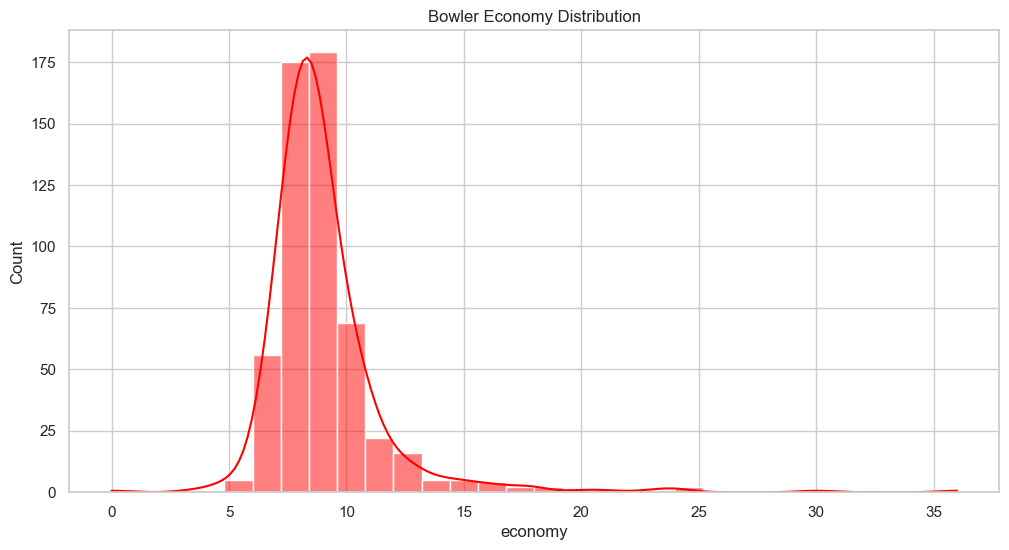

In [7]:
bowler = deliveries.groupby('bowler').agg(
    runs=('total_runs', 'sum'),
    balls=('total_runs', 'count')
)

bowler['economy'] = (bowler['runs'] / (bowler['balls']/6))

sns.histplot(bowler['economy'], bins=30, kde=True, color='red')

plt.title("Bowler Economy Distribution")
plt.show()

## 🧠 CORRELATION ANALYSIS

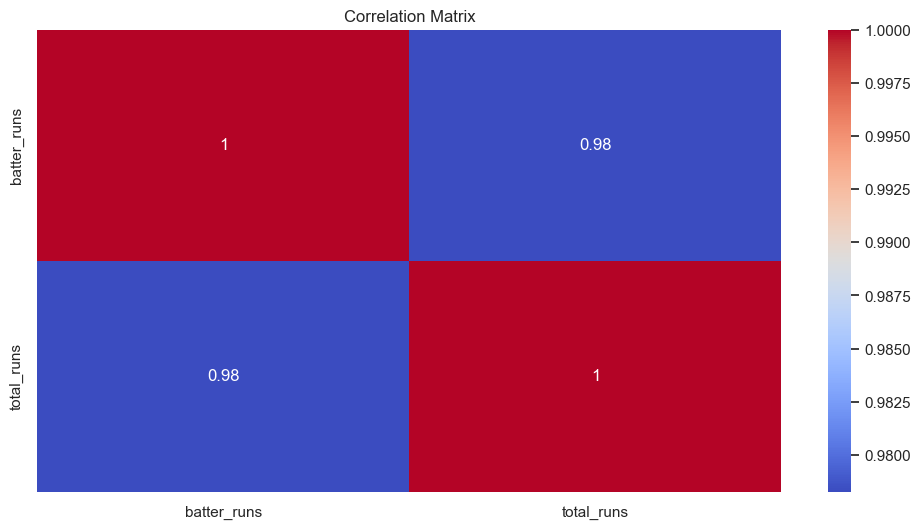

In [8]:
numeric_cols = deliveries[['batter_runs', 'total_runs']]

sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

## 📊 MATCH SCORE DISTRIBUTION

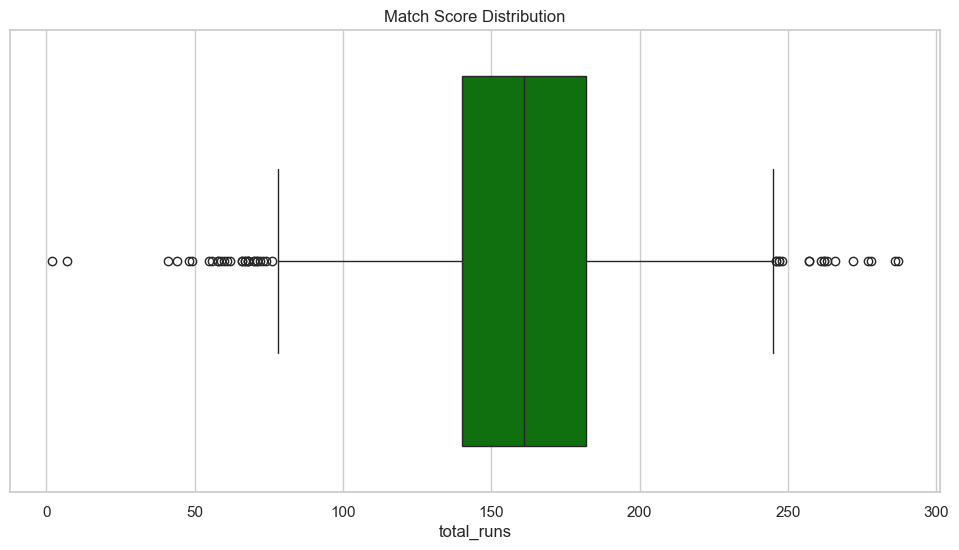

In [9]:
match_scores = deliveries.groupby(['match_id','team_batting'])['total_runs'].sum()

sns.boxplot(x=match_scores, color='green')

plt.title("Match Score Distribution")
plt.show()

## 🎲 TOSS WIN PROBABILITY

In [10]:
matches['toss_win_match_win'] = matches['toss_winner'] == matches['match_winner']

prob = matches['toss_win_match_win'].mean()
print("Probability of winning match after winning toss:", prob)

Probability of winning match after winning toss: 0.5115483319076134


## 📉 CONSISTENCY ANALYSIS (STD DEV)

In [11]:
consistency = batsman.copy()
consistency['std_runs'] = deliveries.groupby('batter')['batter_runs'].std()

top_consistent = consistency.sort_values('std_runs').head(10)

top_consistent[['runs','strike_rate','std_runs']]

,runs,strike_rate,std_runs
batter,,,
S Ladda,0,0.0,0.0
Abdur Razzak,0,0.0,0.0
SS Cottrell,0,0.0,0.0
ND Doshi,0,0.0,0.0
R Sanjay Yadav,0,0.0,0.0
RG More,2,100.0,0.0
RR Bhatkal,0,0.0,0.0
RP Meredith,0,0.0,0.0
MJ Owen,0,0.0,0.0


## DEATH OVER IMPACT

In [12]:
death = deliveries[deliveries['over_number'] >= 16]

death_runs = death['batter_runs'].mean()
overall_runs = deliveries['batter_runs'].mean()

print("Death Over Avg:", death_runs)
print("Overall Avg:", overall_runs)

Death Over Avg: 1.5376077173013663
Overall Avg: 1.2773781923401808


## 📊 SEASON TREND (STAT VIEW)

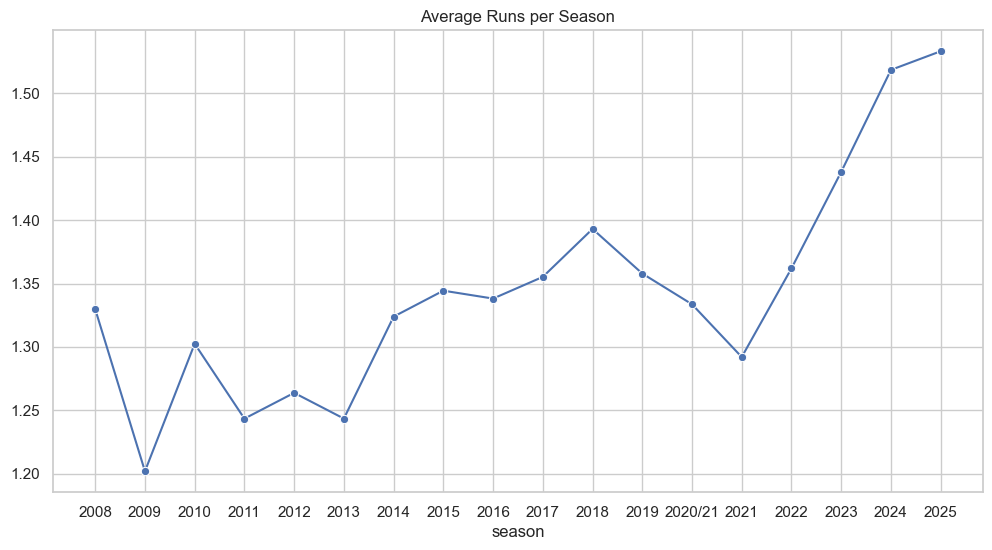

In [13]:
merged = matches.merge(deliveries, on='match_id')

season_avg = merged.groupby('season')['total_runs'].mean()

sns.lineplot(x=season_avg.index, y=season_avg.values, marker='o')

plt.title("Average Runs per Season")
plt.show()

## 📌 CONCLUSION

## ✅ Key Statistical Insights

- Most deliveries result in low runs (0–1)
- Strike rate follows a near-normal distribution
- Toss has moderate impact (~50–55%)
- Death overs significantly increase scoring
- Some players show high consistency (low variance)

---

## 🚀 Future Work
- Hypothesis testing (t-test)
- Predictive modeling (ML)
- Advanced metrics (Win Probability)